In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
stops = pd.read_csv("stops.txt")
stop_times = pd.read_csv("stop_times.txt")
trips = pd.read_csv("trips.txt")

In [3]:
G = nx.DiGraph()  # directed graph (important for transit)

In [4]:
# add nodes, bus stops
for _, row in stops.iterrows():
    G.add_node(
        row["stop_id"],
        pos=(row["stop_lon"], row["stop_lat"]),
        name=row["stop_name"]
    )

In [5]:
# build edges from stop sequences 
stop_times = stop_times.sort_values(["trip_id", "stop_sequence"])

In [6]:
for trip_id, group in stop_times.groupby("trip_id"):
    stops_in_trip = group["stop_id"].tolist()
    
    for i in range(len(stops_in_trip) - 1):
        u = stops_in_trip[i]
        v = stops_in_trip[i + 1]
        
        G.add_edge(u, v)

In [7]:
# add weights based on travel times
# Convert times to seconds
def to_seconds(t):
    h, m, s = map(int, t.split(":"))
    return h*3600 + m*60 + s

stop_times["arrival_sec"] = stop_times["arrival_time"].apply(to_seconds)

In [8]:
for trip_id, group in stop_times.groupby("trip_id"):
    group = group.sort_values("stop_sequence")
    
    for i in range(len(group) - 1):
        u = group.iloc[i]
        v = group.iloc[i + 1]
        
        travel_time = v["arrival_sec"] - u["arrival_sec"]
        
        G.add_edge(
            u["stop_id"],
            v["stop_id"],
            weight=travel_time
        )

In [9]:
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 13771
Edges: 15178


## Plot network

In [12]:
import geopandas as gpd
from shapely.geometry import Point

node_data = []

for node, data in G.nodes(data=True):
    lon, lat = data["pos"]
    node_data.append({
        "stop_id": node,
        "geometry": Point(lon, lat)
    })

nodes_gdf = gpd.GeoDataFrame(node_data, crs="EPSG:4326")

In [13]:
from shapely.geometry import LineString

edge_data = []

for u, v in G.edges():
    lon1, lat1 = G.nodes[u]["pos"]
    lon2, lat2 = G.nodes[v]["pos"]
    
    edge_data.append({
        "u": u,
        "v": v,
        "geometry": LineString([(lon1, lat1), (lon2, lat2)])
    })

edges_gdf = gpd.GeoDataFrame(edge_data, crs="EPSG:4326")

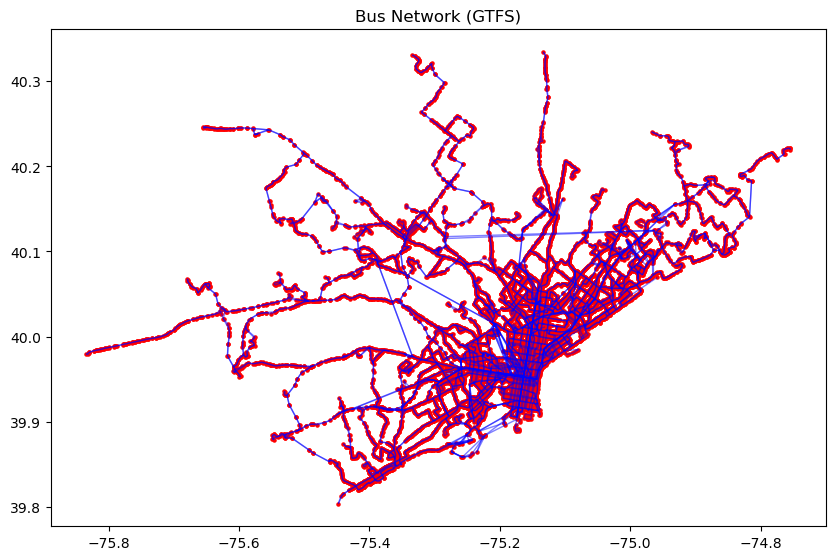

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

edges_gdf.plot(ax=ax, linewidth=1, color="blue", alpha=0.5)
nodes_gdf.plot(ax=ax, markersize=5, color="red")

plt.title("Bus Network (GTFS)")
plt.show()

## Highlight important nodes (like top betweenness)

In [15]:
# Betweenness centrality (bottlenecks)

#Nodes that many shortest paths pass through
# Great for identifying critical connectors / choke points

betweenness = nx.betweenness_centrality(G, k=100, weight="weight")


sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:25]

[(1148, 0.2735438303435253),
 (32989, 0.166846660372334),
 (23308, 0.11361948338054084),
 (5, 0.1135475827341613),
 (22407, 0.11333188079502265),
 (23311, 0.11325998014864311),
 (10266, 0.1090542765148764),
 (6233, 0.1033366015445324),
 (6237, 0.10326470089815284),
 (20587, 0.1031928002517733),
 (6251, 0.10312089960539375),
 (6234, 0.1030489989590142),
 (20550, 0.10297709831263466),
 (699, 0.10290519766625511),
 (18394, 0.09986975573147408),
 (18395, 0.09979785508509453),
 (24116, 0.09972595443871499),
 (24117, 0.09965405379233544),
 (18396, 0.09958215314595589),
 (18397, 0.09951025249957633),
 (226, 0.09943835185319679),
 (20592, 0.09878216767133899),
 (6232, 0.09871026702495944),
 (30187, 0.09690984578884934),
 (21198, 0.09649841431234416)]

In [16]:
top_nodes = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:15]
top_ids = [node for node, _ in top_nodes]

top_nodes_gdf = nodes_gdf[nodes_gdf["stop_id"].isin(top_ids)]

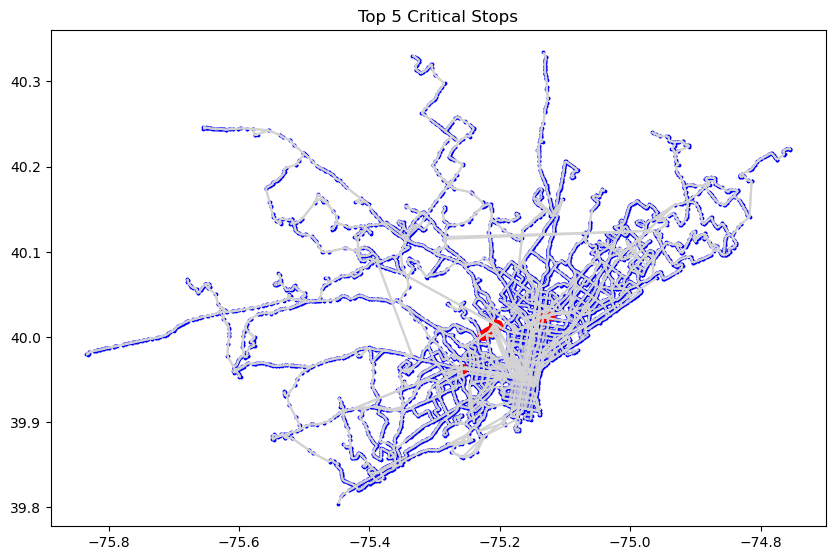

In [17]:
fig, ax = plt.subplots(figsize=(10, 10))

edges_gdf.plot(ax=ax, color="lightgray")
nodes_gdf.plot(ax=ax, color="blue", markersize=3)

top_nodes_gdf.plot(ax=ax, color="red", markersize=50)

plt.title("Top 5 Critical Stops")
plt.show()

### Interactive Folium Map

In [11]:
# conda install -c conda-forge folium

In [18]:
import folium

# Center map
center = [nodes_gdf.geometry.y.mean(), nodes_gdf.geometry.x.mean()]
m = folium.Map(location=center, zoom_start=12)

In [19]:
for _, row in edges_gdf.iterrows():
    coords = [(y, x) for x, y in row.geometry.coords]
    
    folium.PolyLine(
        coords,
        color="blue",
        weight=2,
        opacity=0.5
    ).add_to(m)

In [20]:
for _, row in nodes_gdf.iterrows():
    folium.CircleMarker(
        location=(row.geometry.y, row.geometry.x),
        radius=2,
        color="red"
    ).add_to(m)

In [ ]:
# launch folium map
m

# to shut down map, comment out map object (m) and rerun cell

In [22]:
for _, row in top_nodes_gdf.iterrows():
    folium.CircleMarker(
        location=(row.geometry.y, row.geometry.x),
        radius=8,
        color="yellow",
        fill=True
    ).add_to(m)

In [25]:
## Other stats

In [26]:
# total network length
total_length = sum(data["weight"] for u, v, data in G.edges(data=True))
total_length

np.int64(685598)

In [27]:
nx.density(G)

8.00414836162023e-05

In [28]:
 # edge betweeness 
 # High-traffic segments

edge_bet = nx.edge_betweenness_centrality(G, k=50, weight="weight")

top_edges = sorted(edge_bet.items(), key=lambda x: x[1], reverse=True)[:10]
top_edges

[((23308, 5), 0.11154635681433064),
 ((5, 22407), 0.11132849189058337),
 ((22407, 23311), 0.11125587024933428),
 ((19536, 21484), 0.107760348583878),
 ((164, 17277), 0.09554296780440572),
 ((17277, 17282), 0.09517985959816025),
 ((17282, 17283), 0.09510723795691116),
 ((17283, 17288), 0.09481675139191478),
 ((17288, 17291), 0.0946715081094166),
 ((17291, 165), 0.09445364318566933)]